In [1]:
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib as mpl
from matplotlib import font_manager as fm
import arabic_reshaper
from bidi.algorithm import get_display

#ّFont Setting
def fa(text):
    return get_display(arabic_reshaper.reshape(str(text)))

font_path = r"C:\USERS\HWI\APPDATA\LOCAL\MICROSOFT\WINDOWS\FONTS\B-NAZANIN.TTF"
fm.fontManager.addfont(font_path)
bnazanin = fm.FontProperties(fname=font_path)

mpl.rcParams['font.family'] = bnazanin.get_name()
mpl.rcParams['axes.unicode_minus'] = False

#Data setting
with open('../../Settings.yaml', 'r') as file:
    Setting = yaml.safe_load(file)


#Calling Dataset
file_name = 'Adjusted.xlsx'
file_path = f"{Setting['Output_Path_Ajusted']}/{file_name}"
sheet_name = 'Dataset_for_Model'
Dataset_For_Model = pd.read_excel(file_path,sheet_name = sheet_name)

file_name_1 = "Unadjusted.xlsx"
sheet_name_1 = 'Capital_Stock_By_Activity'
file_path_1 = f"{Setting['Output_Path_Unajusted']}/{file_name_1}"
Investment = pd.read_excel(file_path_1,sheet_name = sheet_name_1)

file_name_2 = 'General.xlsx'
file_path_2 = f"{Setting['Output_Path_General']}/{file_name_2}"
PPI = pd.read_excel(file_path_2, sheet_name='PPI')
PPI = PPI[PPI['Industry_Category_Code'] == 1]
PPI.drop(columns={'Industry_Category_Code','Industry_Name','Industry_Code'},inplace=True)

C:\Users\hwi\AppData\Local\Temp\ipykernel_11596\778138796.py:50: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Local\Temp\ipykernel_11596\778138796.py:50: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)


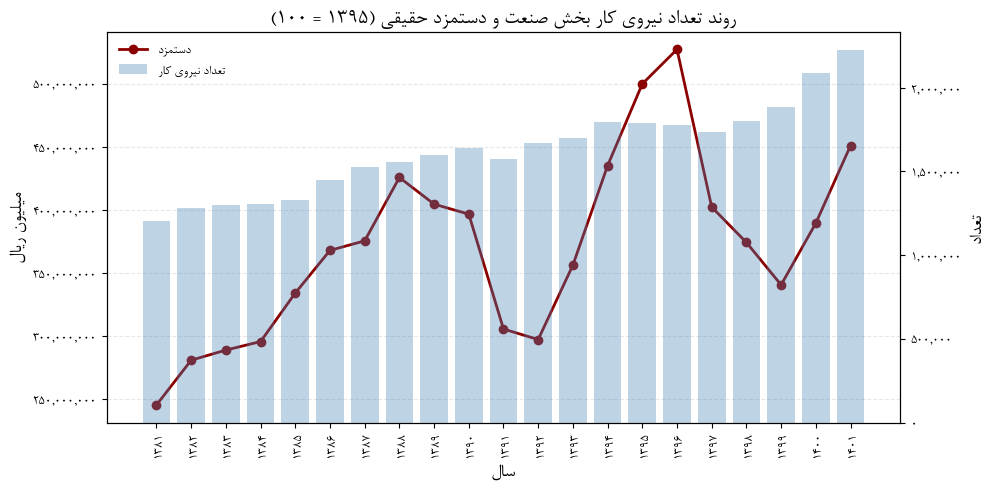

In [2]:
Wage_Info = (   
    Dataset_For_Model.groupby('Year', as_index=False)
    .agg(
        Wage = ('Wage', lambda s: (s.sum() / 10 ** 6 )),
        Labour_No = ('Labour_No', lambda s: s.sum())
        )
)

df = Wage_Info.sort_values('Year').copy()

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(df['Year'], df['Wage'],
         color='darkred', marker='o', linewidth=2, label=fa('دستمزد'))

ax1.set_xlabel(fa('سال'), fontproperties=bnazanin, fontsize=14)
ax1.set_ylabel(fa('میلیون ریال'), fontproperties=bnazanin, fontsize=14)

ax1.set_xticks(df['Year'])
ax1.tick_params(axis='x', labelrotation=90)
ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

ax2 = ax1.twinx()
ax2.bar(df['Year'], df['Labour_No'],
        color='steelblue', alpha=0.35, label=fa('تعداد نیروی کار'))

ax2.set_ylabel(fa('تعداد'), fontproperties=bnazanin, fontsize=14)
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for t in ax1.get_xticklabels() + ax1.get_yticklabels() + ax2.get_yticklabels():
    t.set_fontproperties(bnazanin)

ax1.grid(axis='y', linestyle='--', alpha=0.3)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

leg = ax1.legend(
    h1 + h2, l1 + l2,
    frameon=False,
    loc='upper left' 
)
for t in leg.get_texts():
    t.set_fontproperties(bnazanin)

ax1.set_title(fa('روند تعداد نیروی کار بخش صنعت و دستمزد حقیقی (1395 = 100)'),
              fontproperties=bnazanin, fontsize=16)

fig.subplots_adjust(right=0.72) 
plt.tight_layout()
plt.show()

C:\Users\hwi\AppData\Local\Temp\ipykernel_11596\2579505835.py:45: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Local\Temp\ipykernel_11596\2579505835.py:45: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)


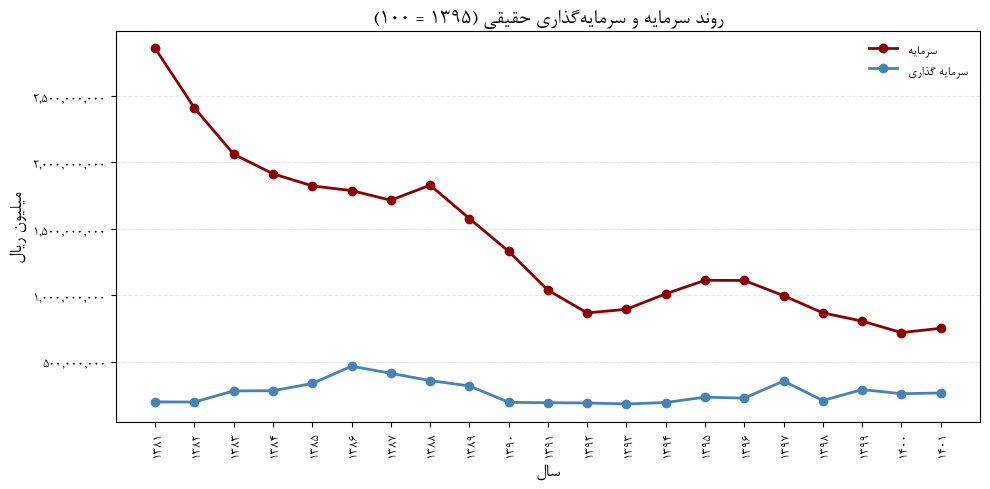

In [3]:
Capital_Info = (
    Dataset_For_Model.groupby('Year', as_index=False)
    .agg(Capital=('Capital', lambda s: s.sum() / 10**6))
)

Investment_By_Year = (
    Investment.groupby('Year', as_index=False)
    .agg(Investment=('Investment', 'sum'))
)

Investment_By_Year = pd.merge(Investment_By_Year, PPI, how='inner', on='Year')
Investment_By_Year['Real_Investment'] = 100 * Investment_By_Year['Investment'] / Investment_By_Year['Price_Index']

df = pd.merge(Investment_By_Year, Capital_Info, how='inner', on='Year').sort_values('Year')

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df['Year'], df['Capital'],
        color='darkred', marker='o', linewidth=2, label=fa('سرمایه'))
ax.plot(df['Year'], df['Real_Investment'],
        color='steelblue', marker='o', linewidth=2, label=fa('سرمایه گذاری'))

ax.set_xlabel(fa('سال'), fontproperties=bnazanin, fontsize=14)
ax.set_ylabel(fa('میلیون ریال'), fontproperties=bnazanin, fontsize=14)

ax.set_xticks(df['Year'])
ax.tick_params(axis='x', labelrotation=90)

ax.ticklabel_format(style='plain', axis='y', useOffset=False)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for t in ax.get_xticklabels() + ax.get_yticklabels():
    t.set_fontproperties(bnazanin)

ax.grid(axis='y', linestyle='--', alpha=0.3)

leg = ax.legend(frameon=False, loc='upper right')
for t in leg.get_texts():
    t.set_fontproperties(bnazanin)

ax.set_title(fa('روند سرمایه و سرمایه‌گذاری حقیقی (1395 = 100)'),
             fontproperties=bnazanin, fontsize=16, fontweight='bold')

fig.subplots_adjust(right=0.78)
plt.tight_layout()
plt.show()

C:\Users\hwi\AppData\Local\Temp\ipykernel_11596\1515694574.py:53: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Local\Temp\ipykernel_11596\1515694574.py:53: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)


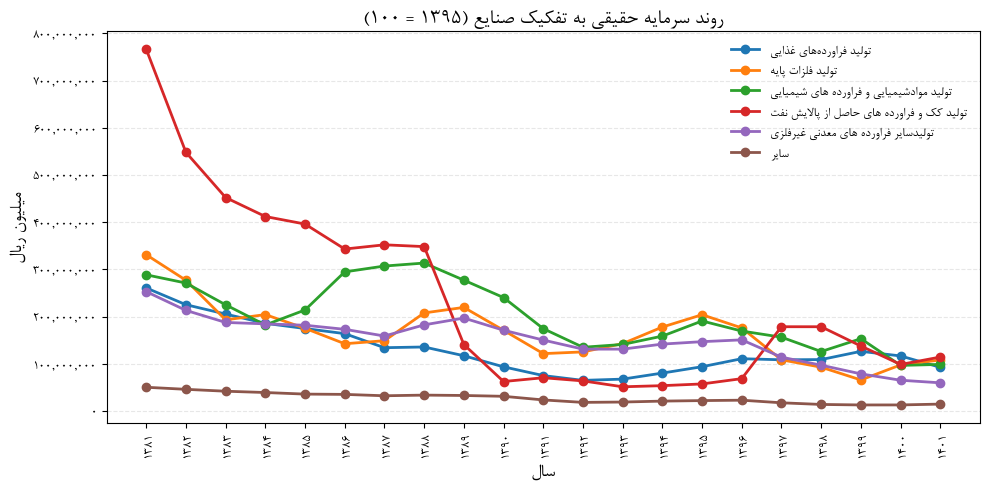

In [4]:

company_col = 'Industry_Name' 
value_col = 'Capital'
d = Dataset_For_Model[[company_col, 'Year', value_col]].copy()
d[value_col] = pd.to_numeric(d[value_col], errors='coerce')

top5 = (d.groupby(company_col)[value_col]
          .sum()
          .sort_values(ascending=False)
          .head(5)
          .index)

top_df = (d[d[company_col].isin(top5)]
          .groupby(['Year', company_col], as_index=False)[value_col]
          .sum())
top_df[value_col] = top_df[value_col] / 10**6

other_avg = (d[~d[company_col].isin(top5)]
             .groupby('Year', as_index=False)[value_col]
             .mean())
other_avg[company_col] = 'سایر'
other_avg[value_col] = other_avg[value_col] / 10**6

plot_df = pd.concat([top_df, other_avg], ignore_index=True)
wide = (plot_df.pivot(index='Year', columns=company_col, values=value_col)
               .sort_index())

fig, ax = plt.subplots(figsize=(10, 5))

for col in wide.columns:
    ax.plot(wide.index, wide[col], linewidth=2, marker='o', label=fa(col))

ax.set_title(fa('روند سرمایه حقیقی به تفکیک صنایع (1395 = 100)'),
             fontproperties=bnazanin, fontsize=16, fontweight='bold')
ax.set_xlabel(fa('سال'), fontproperties=bnazanin, fontsize=14)
ax.set_ylabel(fa('میلیون ریال'), fontproperties=bnazanin, fontsize=14)

ax.set_xticks(wide.index)
ax.tick_params(axis='x', labelrotation=90)

ax.ticklabel_format(style='plain', axis='y', useOffset=False)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for t in ax.get_xticklabels() + ax.get_yticklabels():
    t.set_fontproperties(bnazanin)

ax.grid(axis='y', linestyle='--', alpha=0.3)

leg = ax.legend(frameon=False, loc='upper right')
for t in leg.get_texts():
    t.set_fontproperties(bnazanin)

fig.subplots_adjust(right=0.78)
plt.tight_layout()
plt.show()

C:\Users\hwi\AppData\Local\Temp\ipykernel_11596\284880179.py:36: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Local\Temp\ipykernel_11596\284880179.py:36: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)


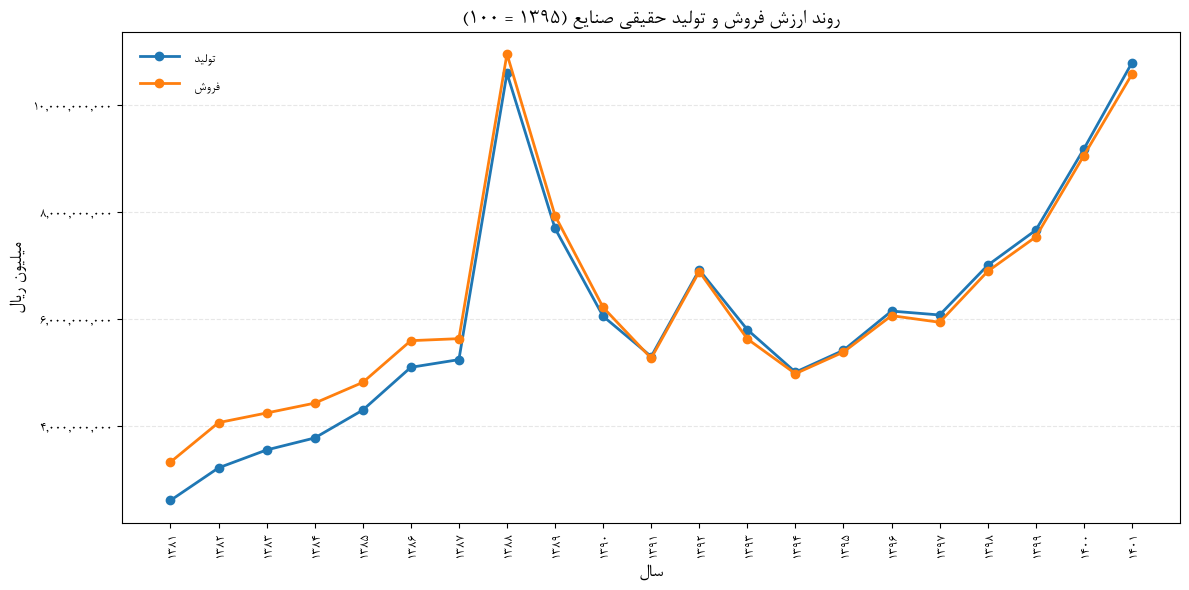

In [5]:
Industry_Info = (
    Dataset_For_Model.groupby('Year', as_index=False)
    .agg(
        Product = ('Product', lambda s: s.sum() / 10**6),
        Sale = ('Sale', lambda s: s.sum() / 10**6)
        )
)

df = Industry_Info.sort_values('Year').copy()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df['Year'], df['Product'], marker='o', linewidth=2, label=fa('تولید'))
ax.plot(df['Year'], df['Sale'],         marker='o', linewidth=2, label=fa('فروش'))

ax.set_title(fa('روند ارزش فروش و تولید حقیقی صنایع (1395 = 100)'), fontproperties=bnazanin, fontsize=16, fontweight='bold')
ax.set_xlabel(fa('سال'), fontproperties=bnazanin, fontsize=14)
ax.set_ylabel(fa('میلیون ریال'), fontproperties=bnazanin, fontsize=14)

ax.set_xticks(df['Year'])
ax.tick_params(axis='x', labelrotation=90)

ax.ticklabel_format(style='plain', axis='y', useOffset=False)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for t in ax.get_xticklabels() + ax.get_yticklabels():
    t.set_fontproperties(bnazanin)

ax.grid(axis='y', linestyle='--', alpha=0.3)

leg = ax.legend(frameon=False, loc='upper left',fontsize = 14)
for t in leg.get_texts():
    t.set_fontproperties(bnazanin)

fig.subplots_adjust(right=0.78)
plt.tight_layout()
plt.show()

C:\Users\hwi\AppData\Local\Temp\ipykernel_11596\2574290761.py:48: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Local\Temp\ipykernel_11596\2574290761.py:48: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Local\Temp\ipykernel_11596\2574290761.py:48: UserWarning: Glyph 8211 (\N{EN DASH}) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8211 (\N{EN DASH}) missing from font(s) B Nazanin.
  f

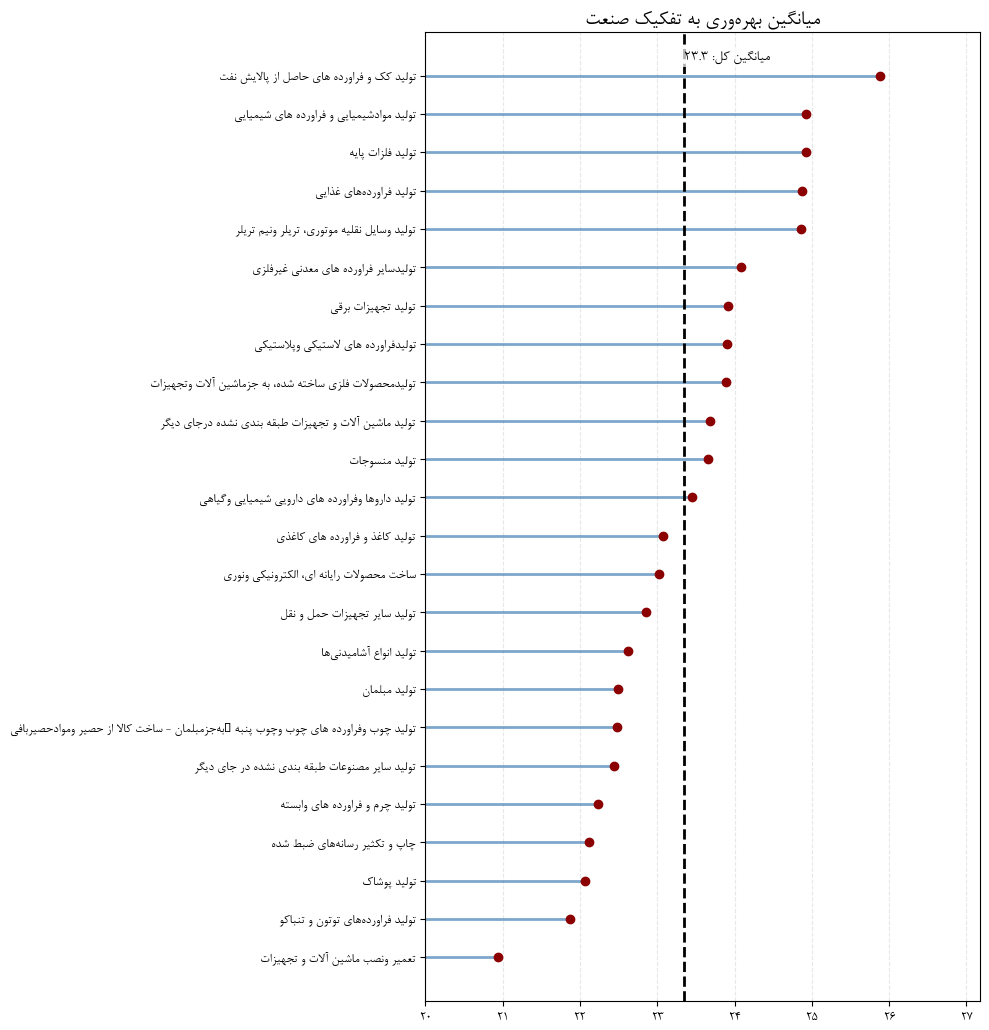

In [6]:
Productivity_Info = (
    Dataset_For_Model.groupby('Industry_Name', as_index=False)
    .agg(Productivity=('Log_Productivity', 'mean'))
).sort_values('Productivity', ascending=True)

overall_mean = Dataset_For_Model['Log_Productivity'].mean()

fig, ax = plt.subplots(figsize=(10, 0.35 * len(Productivity_Info) + 2))

y = np.arange(len(Productivity_Info))

ax.hlines(
    y=y, xmin=0, xmax=Productivity_Info['Productivity'],
    color='steelblue', alpha=0.7, linewidth=2
)
ax.plot(Productivity_Info['Productivity'], y, 'o', color='darkred', markersize=6)

ax.axvline(overall_mean, color='black', linestyle='--', linewidth=2, label=fa('میانگین کل بهره‌وری'))

ax.set_yticks(y)
ax.set_yticklabels([fa(s) for s in Productivity_Info['Industry_Name']], fontproperties=bnazanin)

ax.set_xlabel(fa(''), fontproperties=bnazanin, fontsize=14)
ax.set_title(fa('میانگین بهره‌وری به تفکیک صنعت'),
             fontproperties=bnazanin, fontsize=16, fontweight='bold')

ax.ticklabel_format(style='plain', axis='x', useOffset=False)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
for t in ax.get_xticklabels():
    t.set_fontproperties(bnazanin)

ax.grid(axis='x', linestyle='--', alpha=0.3)

ax.text(
    overall_mean, 0.98,
    fa(f"میانگین کل: {overall_mean:,.1f}"),
    transform=ax.get_xaxis_transform(),
    ha='left', va='top',
    fontproperties=bnazanin, fontsize=11,
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=2)
)

ax.set_xlim(left=20)

for t in leg.get_texts():
    t.set_fontproperties(bnazanin)

plt.tight_layout()
plt.show()

C:\Users\hwi\AppData\Local\Temp\ipykernel_11596\2454183291.py:68: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Local\Temp\ipykernel_11596\2454183291.py:68: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Local\Temp\ipykernel_11596\2454183291.py:68: UserWarning: Glyph 8211 (\N{EN DASH}) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8211 (\N{EN DASH}) missing from font(s) B Nazanin.
  f

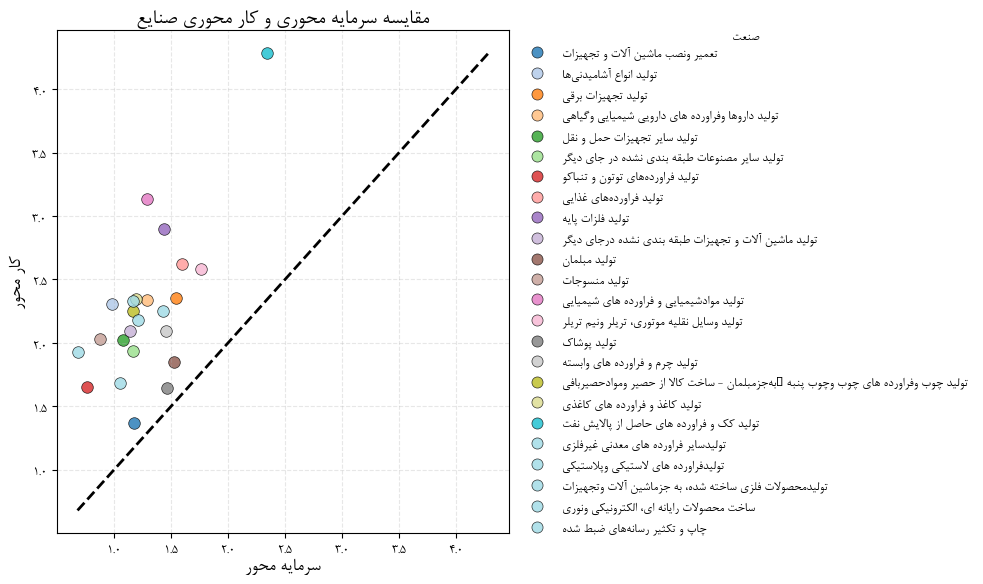

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

Labour_Base_Info = (
    Dataset_For_Model.groupby('Industry_Name', as_index=False)
    .agg(
        Log_Labour_Base=('Log Y/L', 'mean'),
        Log_Capital_Base=('Log Y/K', 'mean')
    )
).sort_values('Industry_Name')

df = Labour_Base_Info.copy()

fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.tab20(np.arange(len(df)))

for i, (_, r) in enumerate(df.iterrows()):
    ax.scatter(
        r['Log_Capital_Base'],
        r['Log_Labour_Base'],
        s=70, alpha=0.8,
        color=colors[i],
        edgecolor='black',
        linewidth=0.5,
        label=fa(r['Industry_Name'])
    )

ax.set_title(fa('مقایسه سرمایه محوری و کار محوری صنایع'),
             fontproperties=bnazanin, fontsize=16, fontweight='bold')
ax.set_xlabel(fa('سرمایه محور'), fontproperties=bnazanin, fontsize=14)
ax.set_ylabel(fa('کار محور'), fontproperties=bnazanin, fontsize=14)

ax.ticklabel_format(style='plain', axis='both', useOffset=False)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.1f}'))
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.1f}'))

for t in ax.get_xticklabels() + ax.get_yticklabels():
    t.set_fontproperties(bnazanin)

ax.grid(True, linestyle='--', alpha=0.3)

xmin = np.nanmin([df['Log_Capital_Base'].min(), df['Log_Labour_Base'].min()])
xmax = np.nanmax([df['Log_Capital_Base'].max(), df['Log_Labour_Base'].max()])
ax.plot([xmin, xmax], [xmin, xmax], color='black', linestyle='--', linewidth=2)

leg = ax.legend(
    title=fa('صنعت'),
    frameon=False,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    scatterpoints=1
)
leg.get_title().set_fontproperties(bnazanin)
leg.get_title().set_fontweight('bold')
for t in leg.get_texts():
    t.set_fontproperties(bnazanin)

legend_marker_size = 8
for h in leg.legend_handles:
    try:
        h.set_sizes([legend_marker_size**2])
    except Exception:
        pass

plt.tight_layout()
plt.show()